# H1 — Subjective Transparency / Explainability (F1 / F2 / F3)

> **H1 (verbose feels more transparent).** Subjective transparency is highest
> under the verbose form **F1**, even though the information content is identical
> across forms.

H1 is the **subjective** counterpart to H2: where H2 asks whether the operator's
mental model actually *updated* (objective explicability), H1 asks whether the
verbose form merely *feels* more transparent (subjective explainability). The
study's core claim is that these move in **opposite** directions — F1 feels most
informative (H1), yet F2/F3 leave the operator better calibrated (H2). Section 3
of this notebook puts the two side by side to make that dissociation visible.

**Design**

| Role | Variable | Detail |
|------|----------|--------|
| Independent variable | Explanation **form** | F1 verbose · F2 contrastive · F3 contrastive + actionable. **Within-subjects** — each participant sees all three (Latin-square counterbalanced), each paired with a different gauge set (A/B/C). |
| Primary DV | **Subjective transparency** | `subj_transparency` ∈ [1, 7], the mean of three agreement sliders (one reverse-keyed). Higher = the form *feels* more transparent. |

## How H1 is measured (the 3-item transparency scale)

After each block — *after* the objective mental-model probe, so that reflection on
the subjective items cannot contaminate the probe — three `genericscales` sliders
capture the *feeling* of being informed. Each is a 1–7 agreement item; one is
reverse-keyed and folded back onto the transparency direction before averaging
(scoring lives in `matb_analysis/metrics_questionnaire.py`):

- **what** — “The system told me what it was doing.” *(strongly disagree–strongly agree)*
- **keep-track** — “It was hard to keep track of what the automation was doing.” *(reverse-scored)*
- **info-volume** — “The amount of information the system gave me felt about right.” *(strongly disagree–strongly agree)*

The three items are averaged into a single composite `subj_transparency` (1–7,
higher = feels more transparent). Because the information content is held constant
across forms, any difference between forms is attributable to *linguistic form*
alone — the verbose stream (F1) is predicted to feel the most informative.

We report **descriptive statistics and visualisations**.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matb_analysis.aggregate import build_metrics_table
from matb_analysis.discovery import find_study_sessions, DEFAULT_SESSIONS_DIR
from matb_analysis.validation import validate_sessions

sns.set_theme(style="whitegrid")
FORM_ORDER = ["F1", "F2", "F3"]
FORM_LABELS = {"F1": "F1\nverbose", "F2": "F2\ncontrastive", "F3": "F3\n+actionable"}
OUT = Path.cwd().parent / "outputs"
OUT.mkdir(exist_ok=True)

# default session_logs once real participants are collected. Whichever directory
# actually contains study sessions is used.
CANDIDATES = [Path.cwd().parent / "session_logs", DEFAULT_SESSIONS_DIR]
DATA_DIR = next((d for d in CANDIDATES if find_study_sessions(d)), CANDIDATES[0])

## 1. Load the sessions and build the H1 metrics table

`find_study_sessions()` reads every study session under `DATA_DIR`. Each session
contributes three rows (one per form). The subjective-transparency composite is
produced by `build_metrics_table()`, which averages the three agreement sliders
(reverse-keying the “hard to keep track” item) into `subj_transparency`.

In [2]:
sessions = find_study_sessions(DATA_DIR)
print(f"Reading logs from: {DATA_DIR}")
print(f"Discovered {len(sessions)} study session(s).")

table = build_metrics_table(sessions)
H1_COLS = ["subj_transparency"]
(table[["participant", "form", "block"] + H1_COLS]
    .sort_values(["participant", "form"]).reset_index(drop=True))

Reading logs from: c:\Projects\HumanCenteredAI\Analysis\session_logs
Discovered 6 study session(s).


,participant,form,block,subj_transparency
0,P01,F1,A,4.902363
1,P01,F2,B,3.594914
2,P01,F3,C,2.427608
3,P02,F1,A,7.000000
4,P02,F2,C,4.621190
5,P02,F3,B,3.286814
6,P03,F1,B,5.414654
7,P03,F2,A,4.968344
8,P03,F3,C,5.000000
9,P04,F1,C,7.000000


### 1b. Sanity check: design realised as intended

Each session is cross-checked against the Latin-square design (form ↔ block order,
panel form vs. briefing). Every participant should contribute exactly one block per
form, so that each form is rated against all three gauge sets equally across the
cohort. Any `ok = False` row must be resolved before trusting that session.

In [3]:
report = validate_sessions(sessions)
n_bad = int((~report["ok"]).sum()) if not report.empty else 0
print(f"{len(report)} session(s) validated; {n_bad} with design issues.")

print(f"\nParticipants: {table['participant'].nunique()}")
print("Blocks per form (should be equal):")
print(table["form"].value_counts().reindex(FORM_ORDER).to_string())
print("\nform x gauge-set (counterbalancing):")
print(pd.crosstab(table["form"], table["block"]).reindex(FORM_ORDER).to_string())

6 session(s) validated; 0 with design issues.

Participants: 6
Blocks per form (should be equal):
form
F1    6
F2    6
F3    6

form x gauge-set (counterbalancing):
block  A  B  C
form          
F1     2  2  2
F2     2  2  2
F3     2  2  2


## 2. Primary DV — subjective transparency by form

Descriptive statistics of `subj_transparency` (the 1–7 composite, higher = the
form *feels* more transparent) for each form. H1 predicts the verbose form **F1**
to sit **above** the contrastive forms F2 / F3.

In [4]:
def describe(df, col):
    g = df.groupby("form")[col]
    out = pd.DataFrame({
        "n_blocks": g.size(),
        "mean": g.mean(),
        "sd": g.std(),
        "median": g.median(),
        "min": g.min(),
        "max": g.max(),
    }).reindex(FORM_ORDER).round(3)
    return out

describe(table, "subj_transparency")

,n_blocks,mean,sd,median,min,max
form,,,,,,
F1,6,5.778,0.960,5.306,4.902,7.0
F2,6,5.041,1.193,4.795,3.595,7.0
F3,6,4.392,1.921,4.143,2.428,7.0


**Figure 1 — distribution of subjective transparency by form.** Box = median
and interquartile range; whiskers = range; each dot is one block. H1 predicts the
F1 distribution to sit above F2/F3 (higher = feels more transparent).

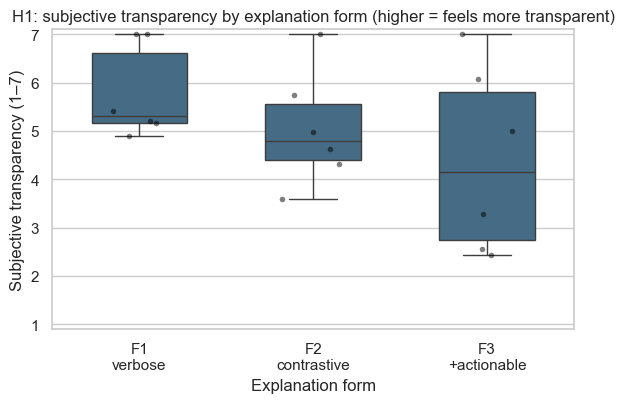

In [5]:
fig, ax = plt.subplots(figsize=(6, 4.2))
sns.boxplot(data=table, x="form", y="subj_transparency", order=FORM_ORDER,
            color="#3b6e8f", width=0.55, ax=ax)
sns.stripplot(data=table, x="form", y="subj_transparency", order=FORM_ORDER,
              color="black", alpha=0.5, size=4, jitter=0.18, ax=ax)
ax.set_ylim(0.9, 7.1)
ax.set_xlabel("Explanation form")
ax.set_ylabel("Subjective transparency (1–7)")
ax.set_xticks(range(len(FORM_ORDER)))
ax.set_xticklabels([FORM_LABELS[f] for f in FORM_ORDER])
ax.set_title("H1: subjective transparency by explanation form (higher = feels more transparent)")
fig.tight_layout()
fig.savefig(OUT / "h1_transparency_by_form.png", dpi=150)
plt.show()

**Figure 2 — within-subject view.** Each grey line is one participant across the
three forms; the thick line is the mean. Because the design is within-subjects,
this shows whether *individuals* tend to feel more informed under F1, not just the
group average.

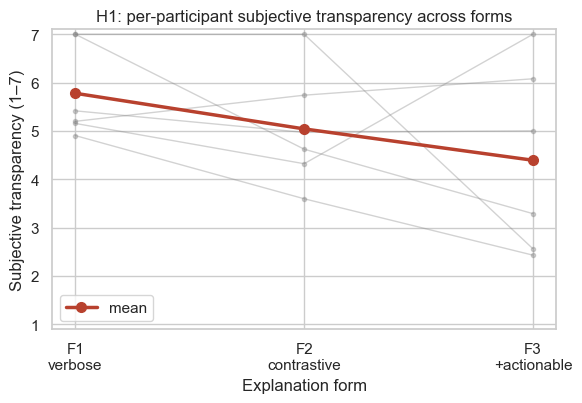

In [6]:
wide = table.pivot_table(index="participant", columns="form", values="subj_transparency")
wide = wide.reindex(columns=FORM_ORDER)

fig, ax = plt.subplots(figsize=(6, 4.2))
x = np.arange(len(FORM_ORDER))
for _, row in wide.iterrows():
    ax.plot(x, row.values, color="grey", alpha=0.35, marker="o", markersize=3,
            linewidth=1)
ax.plot(x, wide.mean(axis=0).values, color="#b8412e", marker="o", markersize=7,
        linewidth=2.5, label="mean")
ax.set_xticks(x)
ax.set_xticklabels([FORM_LABELS[f] for f in FORM_ORDER])
ax.set_ylim(0.9, 7.1)
ax.set_xlabel("Explanation form")
ax.set_ylabel("Subjective transparency (1–7)")
ax.set_title("H1: per-participant subjective transparency across forms")
ax.legend()
fig.tight_layout()
fig.savefig(OUT / "h1_transparency_perparticipant.png", dpi=150)
plt.show()

## 3. The H1↔H2 dissociation — feeling vs. knowing

The load-bearing claim of the study is that **explainability** (H1, the *feeling*
of being informed) and **explicability** (H2, whether the mental model actually
*updated*) move in **opposite** directions across forms. This section puts the two
composites side by side so the predicted crossover is visible:

- `subj_transparency` (1–7, H1) — predicted **highest under F1** (the verbose stream feels most informative).
- `mm_explicability` (0–1, H2) — predicted **highest under F2/F3** (the contrastive panel leaves a better-calibrated model).

If the two lines cross — F1 on top for transparency, F2/F3 on top for explicability
— the same fixed information content has produced a *feeling* of transparency that
diverges from what the operator actually *knows*. That dissociation is the whole
point: an explanation can raise the feeling of being informed without improving
the mental model.

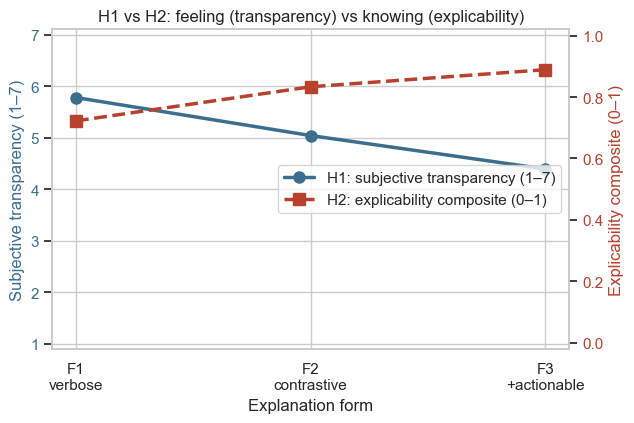

In [7]:
means = (table.groupby("form")[["subj_transparency", "mm_explicability"]]
              .mean().reindex(FORM_ORDER))

fig, ax1 = plt.subplots(figsize=(6.5, 4.4))
x = np.arange(len(FORM_ORDER))

l1, = ax1.plot(x, means["subj_transparency"].values, color="#3b6e8f",
               marker="o", markersize=8, linewidth=2.5,
               label="H1: subjective transparency (1–7)")
ax1.set_ylabel("Subjective transparency (1–7)", color="#3b6e8f")
ax1.tick_params(axis="y", labelcolor="#3b6e8f")
ax1.set_ylim(0.9, 7.1)

ax2 = ax1.twinx()
l2, = ax2.plot(x, means["mm_explicability"].values, color="#b8412e",
               marker="s", markersize=8, linewidth=2.5, linestyle="--",
               label="H2: explicability composite (0–1)")
ax2.set_ylabel("Explicability composite (0–1)", color="#b8412e")
ax2.tick_params(axis="y", labelcolor="#b8412e")
ax2.set_ylim(-0.02, 1.02)
ax2.grid(False)

ax1.set_xticks(x)
ax1.set_xticklabels([FORM_LABELS[f] for f in FORM_ORDER])
ax1.set_xlabel("Explanation form")
ax1.set_title("H1 vs H2: feeling (transparency) vs knowing (explicability)")
ax1.legend(handles=[l1, l2], loc="center right")
fig.tight_layout()
fig.savefig(OUT / "h1_vs_h2_dissociation.png", dpi=150)
plt.show()

## 4. Compact summary table

One row per form, suitable for the report. H1 predicts the subjective-transparency
composite to be **highest under F1** — the opposite ordering to the H2 explicability
composite (shown alongside to make the dissociation explicit).

In [8]:
SUMMARY_COLS = ["subj_transparency", "mm_explicability"]
summary = (table.groupby("form")[SUMMARY_COLS]
              .agg(["mean", "median", "std"])
              .reindex(FORM_ORDER)
              .round(3))
summary.to_csv(OUT / "h1_subjective_transparency_summary_by_form.csv")
summary

subj_transparency               mm_explicability              
                  mean median    std             mean median    std
form                                                               
F1               5.778  5.306  0.960            0.722  0.667  0.136
F2               5.041  4.795  1.193            0.833  1.000  0.279
F3               4.392  4.143  1.921            0.889  1.000  0.172